### 패키지 및 데이터

In [2]:
from hossam import load_data
from pandas import DataFrame, get_dummies
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm 
import seaborn as sb
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix, roc_curve, accuracy_score, recall_score,  precision_score, f1_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
my_dpi = 200
my_font_name = "./NotoSansKr-Regular.ttf"
fm.fontManager.addfont(fpath)
fprop = fm.FontProperties(fname=fpath)
fname = fprop.get_name()
plt.rcParams['font.family'] = fname
plt.rcParams['font.size'] = 6
plt.rcParams['axes.unicode_minus'] = False

In [4]:
origin = load_data('apple_quality')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

이 데이터 세트는 다양한 과일 속성에 대한 정보를 담고 있어 과일의 특성을 파악하는 데 도움이 됩니다. 데이터 세트에는 과일 ID, 크기, 무게, 당도, 아삭함, 과즙량, 숙성도, 산도 및 품질과 같은 세부 정보가 포함되어 있습니다. (출처: https://www.kaggle.com/datasets/nelgiriyewithana/apple-quality)

field        description
-----------  ----------------------------------
A_id         각 과일에 대한 고유 식별자
Size         크기
Weight       무게
Sweetness    단맛 정도
Crunchiness  과일의 아삭한 식감을 나타내는 질감
Juiciness    과일의 과즙 함량 정도
Ripeness     과일이 익은 정도
Acidity      과일의 산도 수준
Quality      과일의 전반적인 품질


===== 데이터 크기 확인 =====
데이터셋 크기: (4000, 9)
열 개수: 9
행 개수: 4000

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   A_id         4000 non-null   int64  
 1   Size         4000 non-null   float64
 2   Weight       4000 non-null   float64
 3   Sweetness    4000 non-null   float64
 4   Crunchiness  4000 non-null   float64
 5   Juiciness    4000 non-null   fl

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0,-3.970,-2.512,5.346,-1.012,1.845,0.330,-0.492,good
1,1,-1.195,-2.839,3.664,1.588,0.853,0.868,-0.723,good
2,2,-0.292,-1.351,-1.738,-0.343,2.839,-0.038,2.622,bad
3,3,-0.657,-2.272,1.325,-0.098,3.638,-3.414,0.791,good
4,4,1.364,-1.297,-0.385,-0.553,3.031,-1.304,0.502,good


📝2단계. 목표 변수 시각화 - “우리가 맞히려는 대상은 어떤 분포를 가지고 있을까?”<br>
Quality의 분포를 막대그래프로 시각화하자.<br>좋은 사과와 그렇지 않은 사과의 비율을 확인하자.<br>이 분포를 보고 정확도 하나만으로 모델을 평가해도 괜찮을지 고민해 보자.

Good/Bad 이진분류<br>
Good 사과는 전체에서 얼마나 차지?<br>
불량사과의 상대적 비중은 얼마?

In [5]:
# Quality 칼럼 전처리
origin['Quality'].value_counts(dropna = False)


Quality
good    2004
bad     1996
Name: count, dtype: int64

In [6]:
origin['Quality'] = (
    origin['Quality']
    .str.strip()      # 앞뒤 공백 제거
    .str.lower()      # 소문자 통일
)


In [7]:
# 다중클래스 분석을 위해서
origin['Quality_binary'] = origin['Quality'].apply(
    lambda x: 'good' if x == 'good' else 'non-good'
)

In [8]:
# 결측치 처리
origin['Quality_binary'].isna().sum()

0

In [9]:
dif_viz = origin.dropna(subset=['Quality_binary'])

In [10]:
# 중복 데이터 점검
dif_viz.duplicated().sum()

0

In [11]:
# 중복 데이터 없앰
dif_viz = dif_viz.drop_duplicates()

In [12]:
count_df = dif_viz['Quality_binary'].value_counts().reset_index()
count_df.columns = ['Quality','Count']
count_df

,Quality,Count
0,good,2004
1,non-good,1996


In [13]:
count_df['Percentage'] = (
    count_df['Count']/count_df['Count'].sum() * 100
)

print(count_df)


print(f"완벽한 균형 클래스")
print(f"클래스 간의 비율이 약 50:50으로 의도적 편향 거의 없다")


    Quality  Count  Percentage
0      good   2004      50.100
1  non-good   1996      49.900
완벽한 균형 클래스
클래스 간의 비율이 약 50:50으로 의도적 편향 거의 없다


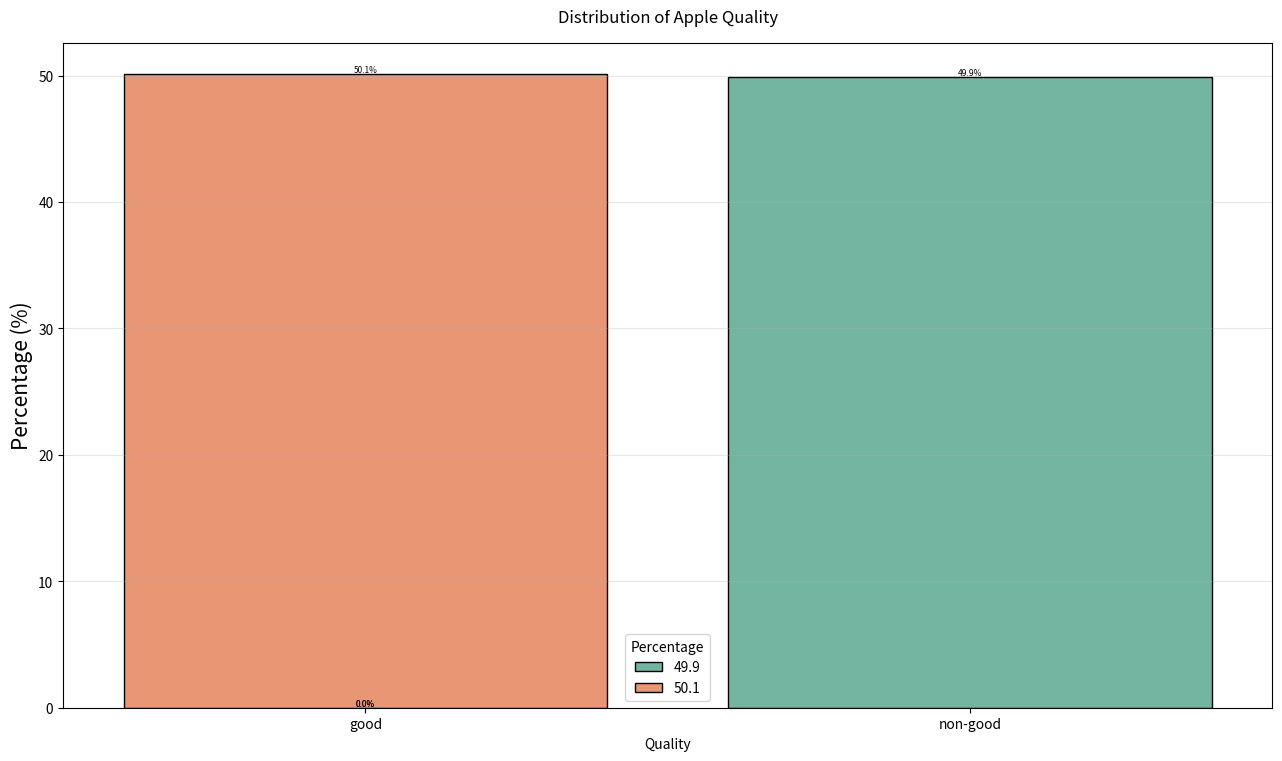

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# figure 설정
width_px = 1280
height_px = 760
my_dpi = 100

figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(figsize=figsize, dpi=my_dpi)


sns.barplot(
    data=count_df,
    x='Quality',
    y='Percentage',
    edgecolor='#000000',
    ax=ax,
    hue='Percentage',
    palette='Set2'
)

ax.set_title("Distribution of Apple Quality", fontsize=12)
ax.set_xlabel("Quality", fontsize=10)
ax.set_ylabel("Percentage (%)", fontsize=15)

# 수치 표시
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height(),
        f"{p.get_height():.1f}%",
        ha='center',
        va='bottom'
    )

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()


미션3

In [15]:
na_sum = origin[['Size','Weight','Sweetness','Juiciness','Ripeness','Acidity']].isna().sum()
print(na_sum)
print(f"연속형 변수의 결측치는 모두 0")

Size         0
Weight       0
Sweetness    0
Juiciness    0
Ripeness     0
Acidity      0
dtype: int64
연속형 변수의 결측치는 모두 0


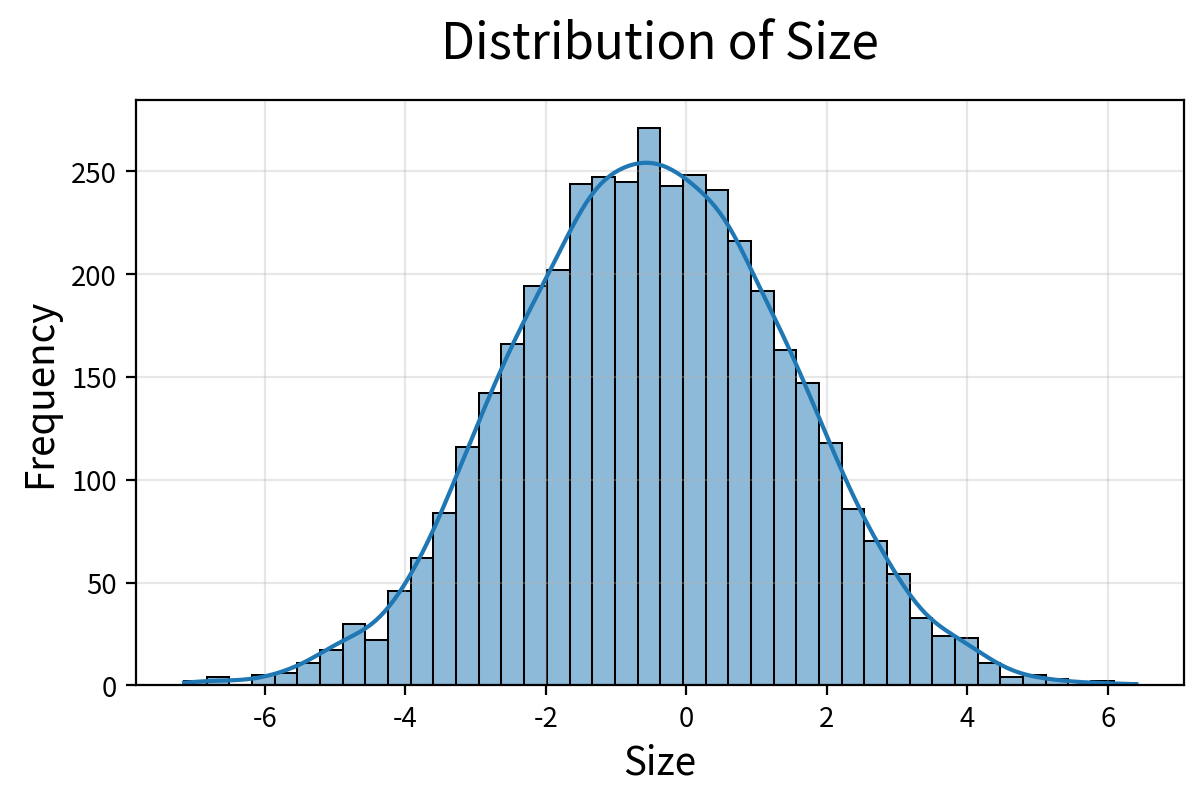

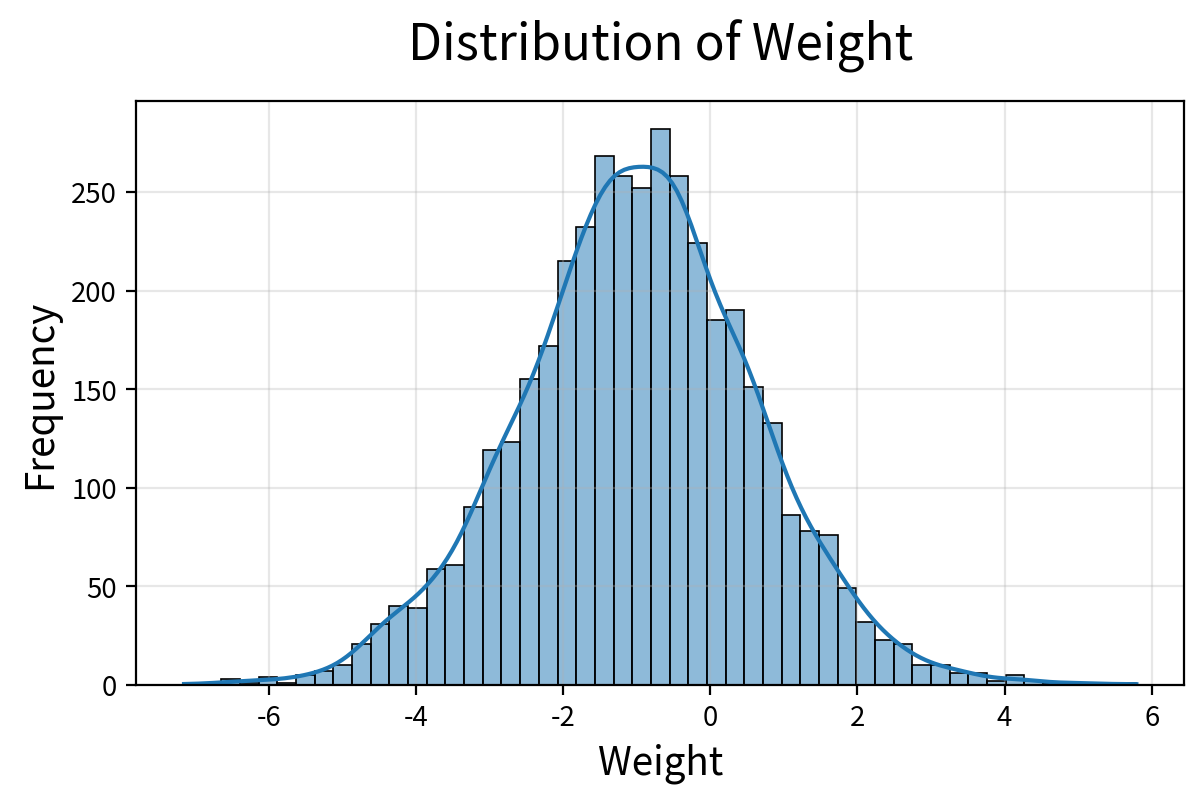

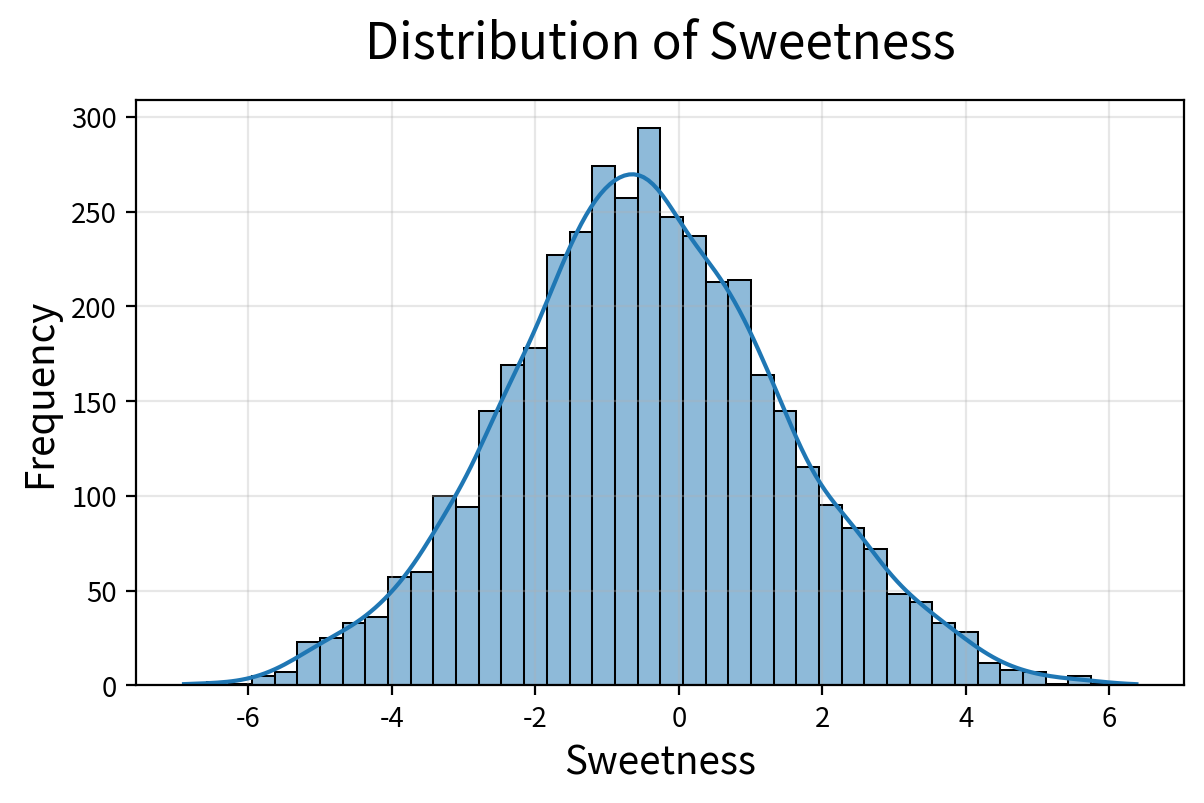

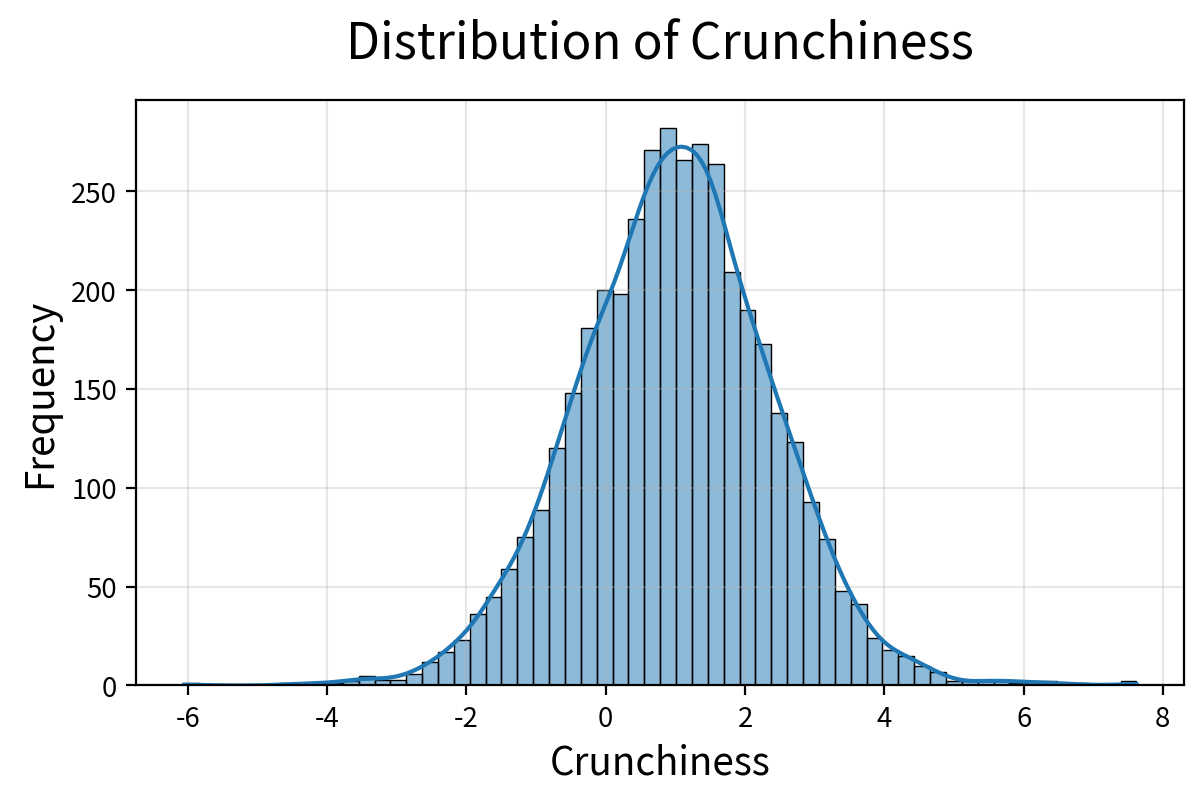

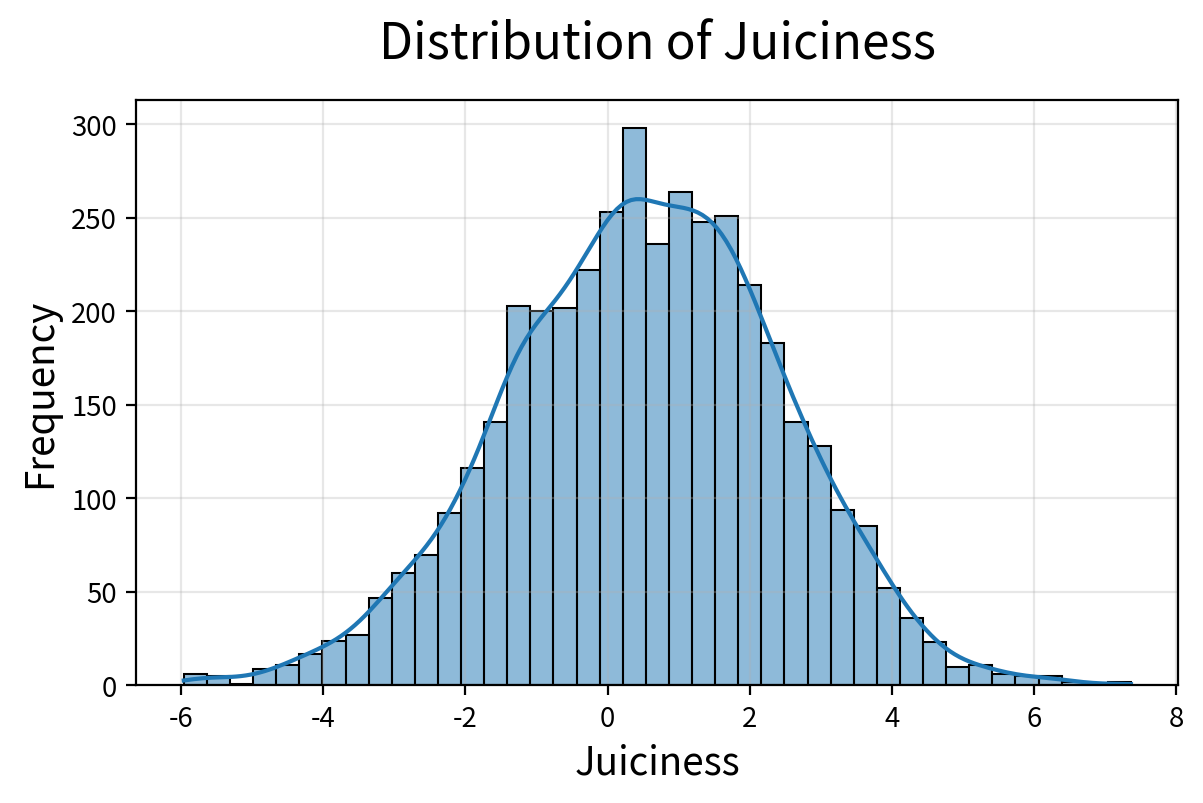

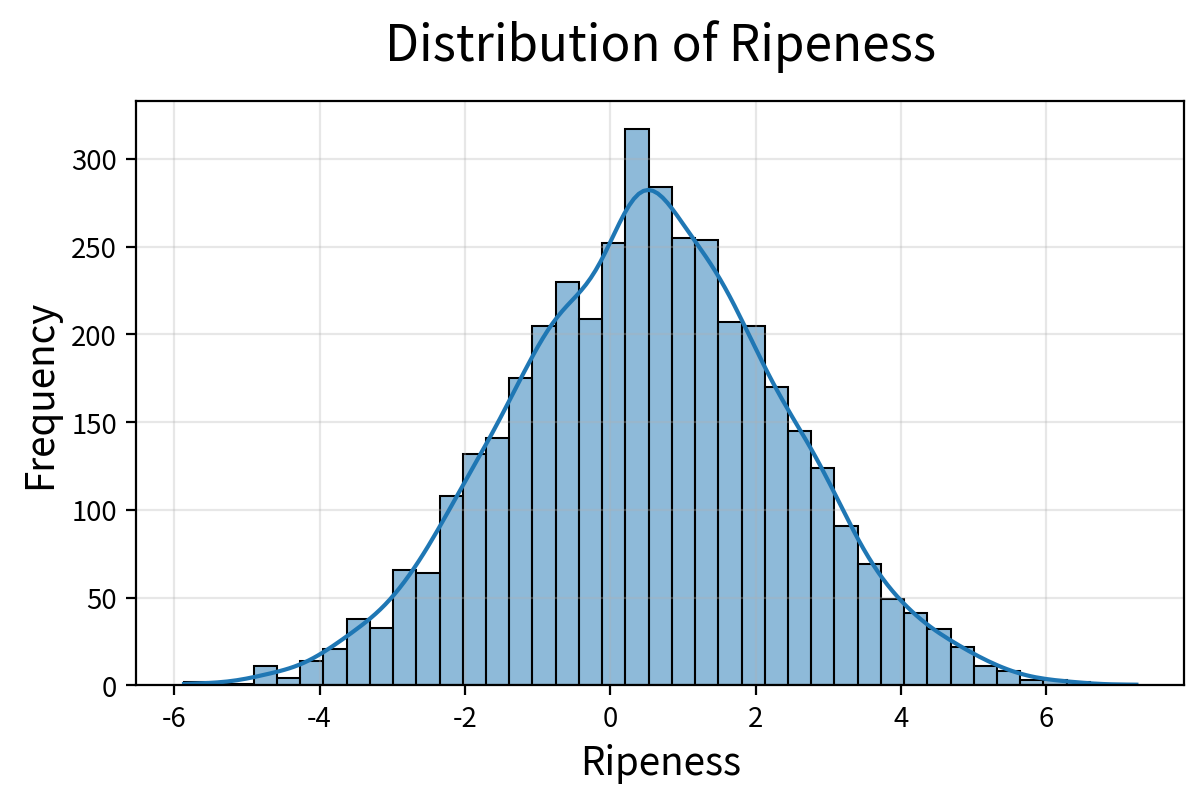

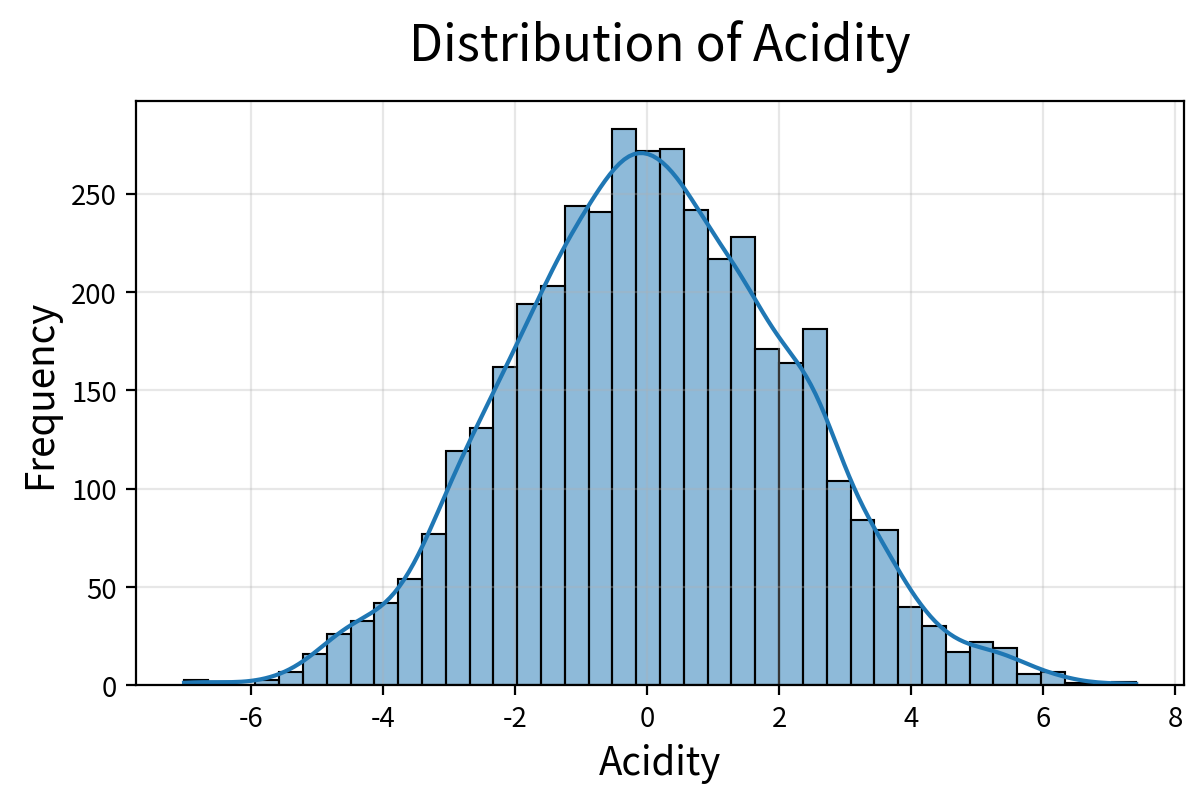

In [16]:
import seaborn as sb
import matplotlib.pyplot as plt
numeric_cols =['Size','Weight','Sweetness','Crunchiness','Juiciness','Ripeness','Acidity']
for col in  numeric_cols:
    plt.figure(figsize=(6,4))


    sb.histplot(data = origin, x=col, kde=True, edgecolor='black')

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.close()


Sweetness->히스토그램 + KDE 모양이 종모양<br>
           좌우가 비교적 대칭<br>
           극단적인 꼬리 없음<br>

Crunchiness -> 분포는 매우 뾰족한 종 모양<br>
               중심부에 값이 강하게 집중<br>
               양쪽 꼬리는 존재하지만 급격한 튐은 없음(이상치 아님)<br>
               맛은 어떨까?<br>

Juiciness->    전반적으로 종 모양의 분포를 보이지만, 왼쪽    꼬리가 상대적으로 길어 약한 음의 왜도를 가지는 경향이 관찰됨

Ripeness ->    중심부에 값 하나가 튐<br>
               왼쪽에 이상치같이 보이는 값이 있음 하지만 이상치는 아님<br>


Acidity ->     정규분포 이룸<br>
               오른쪽으로 양의 왜도를 가지려 함



📝미션4 .이변량 EDA - “품질에 따라 무엇이 달라질까?<br>
Quality를 0,1로 나눴을 때 연속형변수의 값은 어떻게 달라질까?

중앙값 차이가 분명한 변수와 분포가 크게 겹치는 변수를 구분하자.<br>분류에 도움이 될 것 같은 변수를 골라 보자

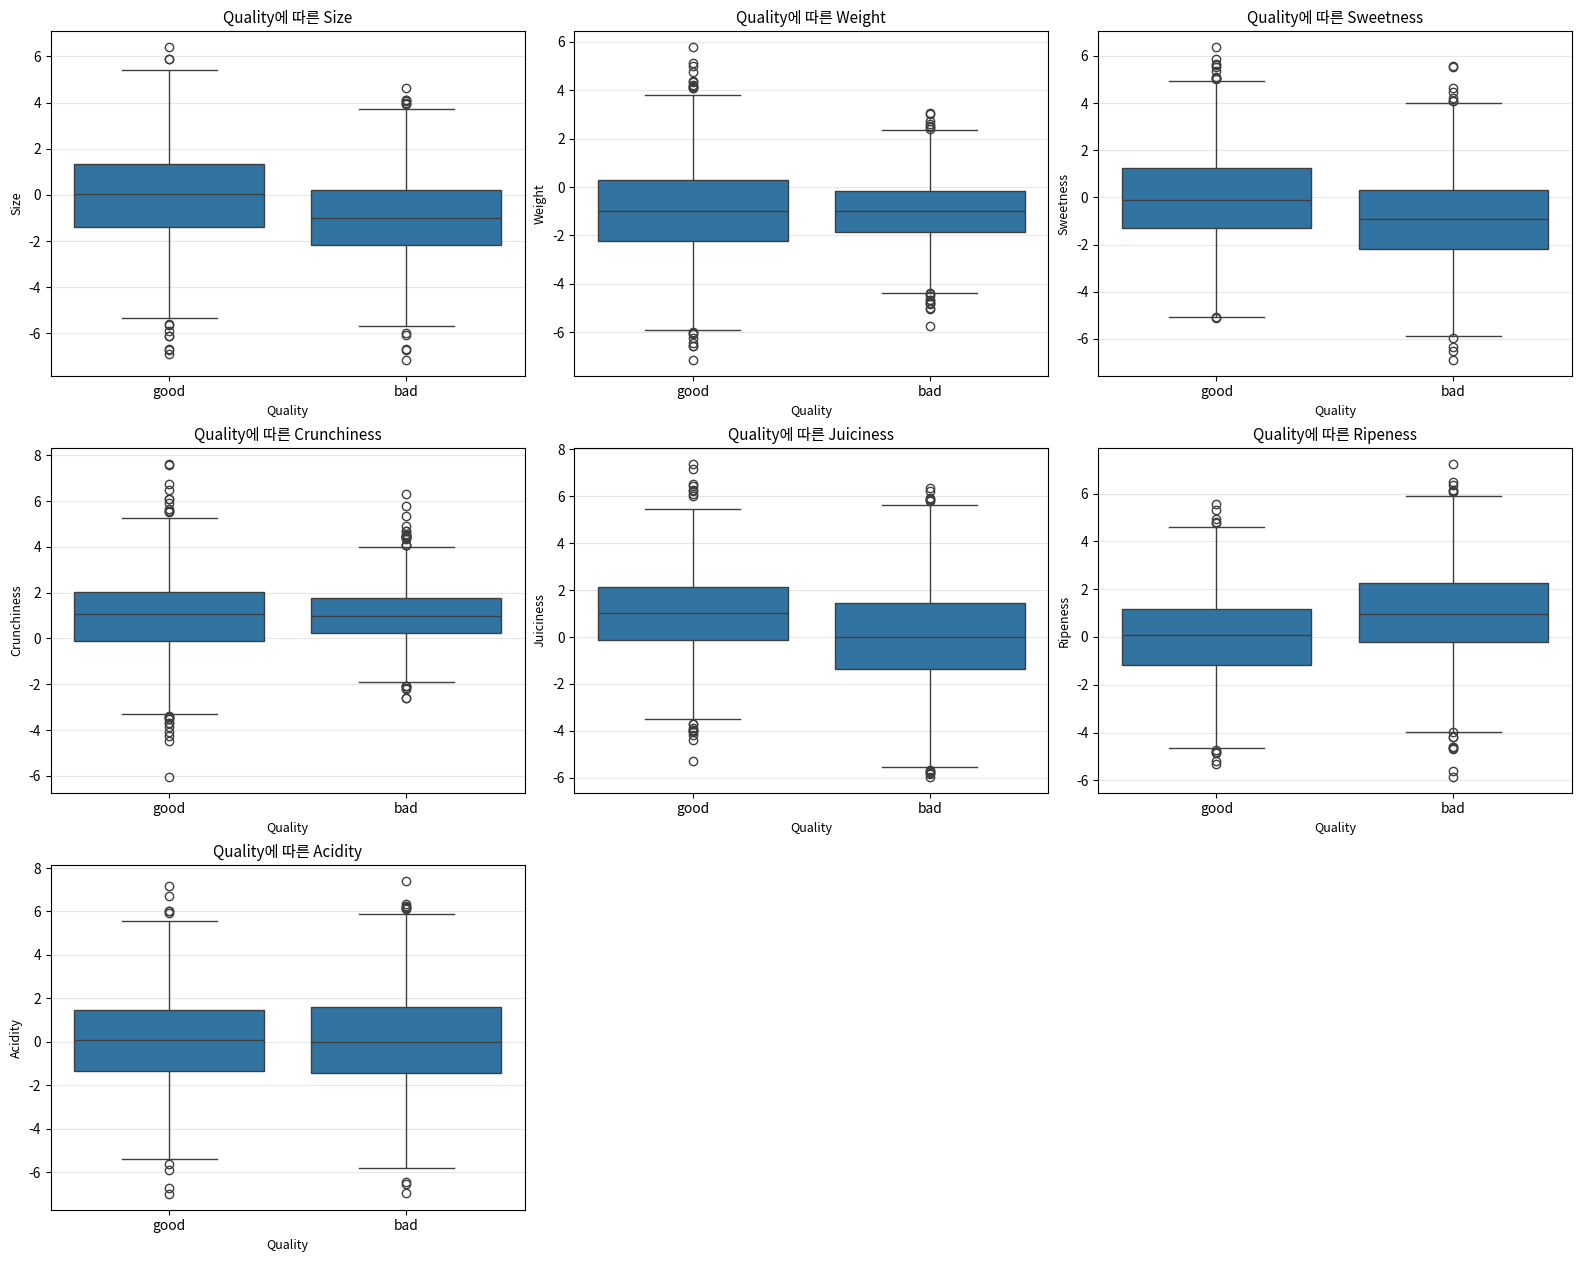

In [17]:
rows, cols = 3, 3

fig, axes = plt.subplots(
    rows, cols,
    figsize=(15.8, 12.6),
    dpi=100,
    
)

for i, col in enumerate(numeric_cols):
    r = i // cols
    c = i % cols

    sb.boxplot(
        data=origin,
        x='Quality',
        y=col,
        ax=axes[r, c]
    )

    axes[r, c].set_title(
        f'Quality에 따른 {col}',
        fontsize=11,
        pad=6
    )

    axes[r, c].set_xlabel('Quality', fontsize=9)
    axes[r, c].set_ylabel(col, fontsize=9)
    axes[r, c].grid(axis='y', alpha=0.3)

# 사용하지 않는 subplot 제거
for j in range(len(numeric_cols), rows * cols):
    r = j // cols
    c = j % cols
    fig.delaxes(axes[r, c])

plt.tight_layout()
plt.show()
plt.close()


양의 상관성이 존재하는 연속형 변수들도 있지만<br>몇가지의 요인들(예:기온, 품종 특성) 때문에 Weight나 Crunchiness에서 예상치 못한 이상치나 분포를 발견할 수 있는 것 같다.
사과의 품질에 영향을 주는 것 같다<br>
또한, 어떠한 변수에서 사분위수 범위가 넓어 중복되는 값이 있을 수도 있다는 생각을 했다.<br>그리하여 중복되는 값을 제거하고 분석을 하는 것도 생각했다. 


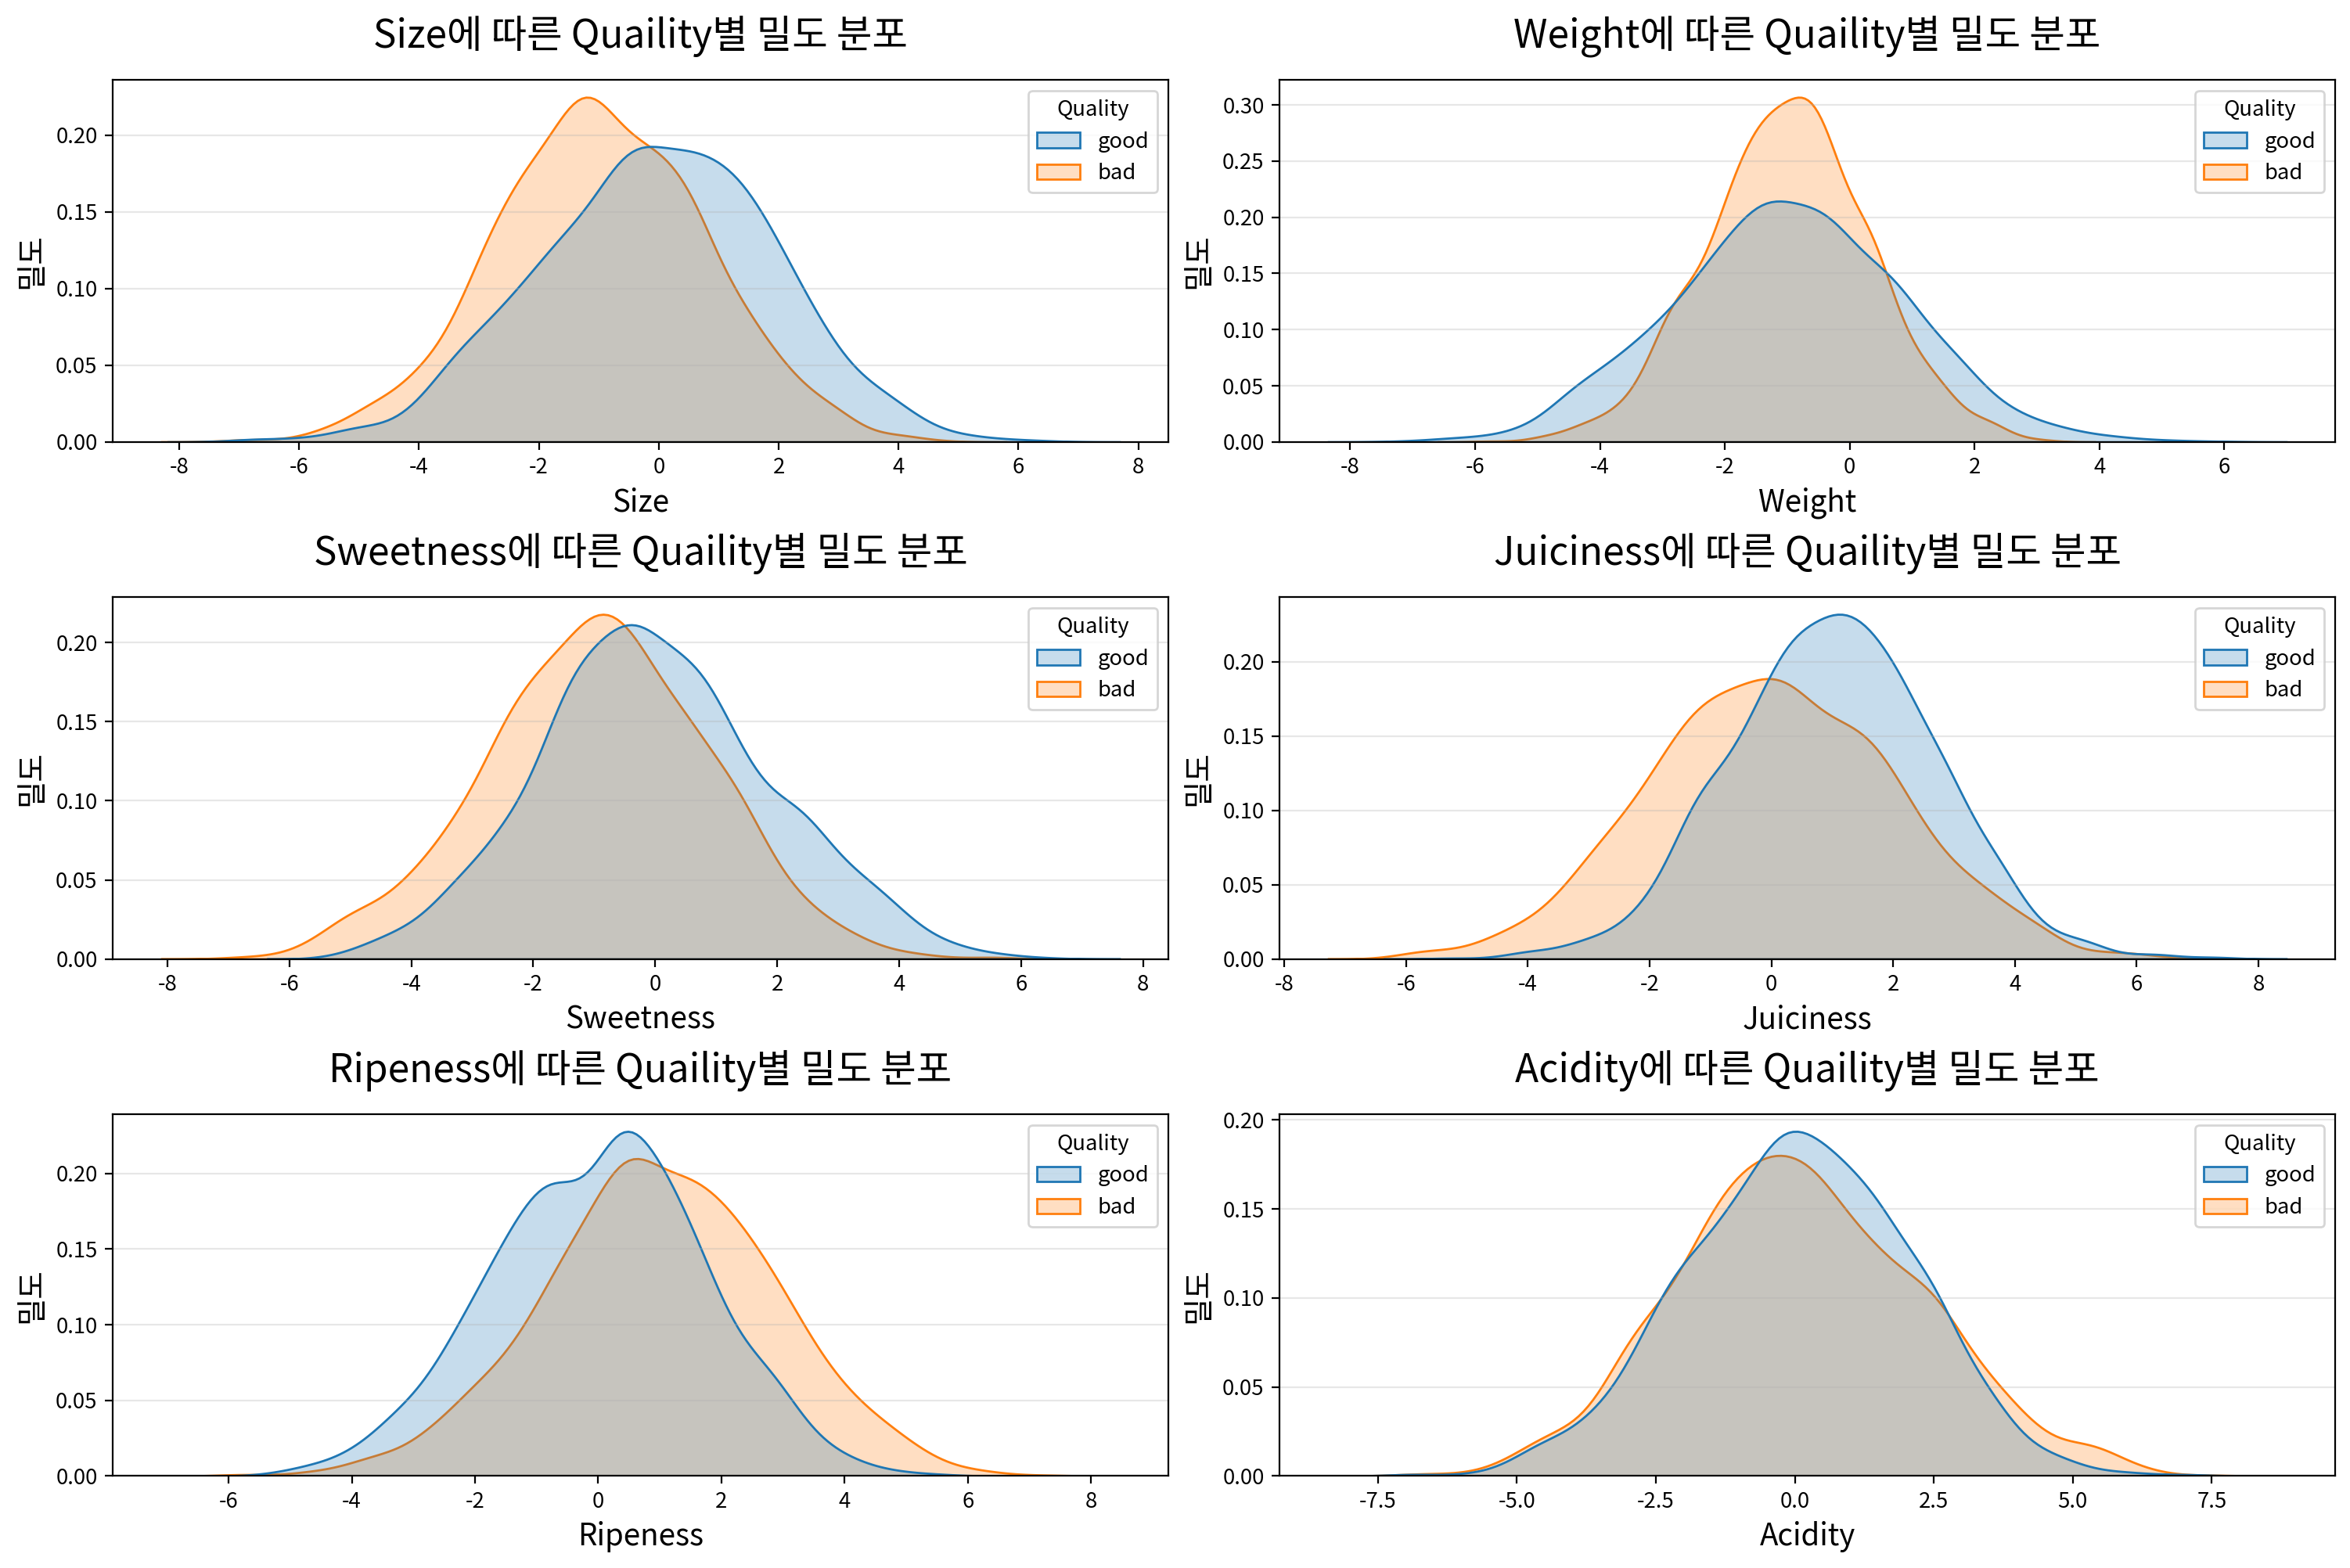

Sweetness가 가장 뚜렷
Juiciness가 그 다음
즉 분포 겹침도가 상대적으로 적어 분류에 기여할 가능성이 높은 변수로 판단
반면, weight,Crunchiness,Acidity는 두 그룹의 분포가 크게 겹쳐 단독 변수로서의 구분력은 제한적으로 보임 


In [18]:
numeric_cols = ['Size', 'Weight', 'Sweetness', 'Juiciness', 'Ripeness', 'Acidity']

# 크기 설정
plt.figure(figsize=(15,10))

for i, col in enumerate(numeric_cols,1):
    plt.subplot(3,2,i)
    sb.kdeplot(data=origin, x=col, hue='Quality', fill=True, common_norm=False)
    plt.title(f'{col}에 따른 Quaility별 밀도 분포')
    plt.xlabel(f'{col}')
    plt.ylabel('밀도')
    plt.grid(True, axis='y', alpha=0.3)

# 서브플롯 간 간격 자동 조절
plt.tight_layout()
plt.show()
print(f"Sweetness가 가장 뚜렷\nJuiciness가 그 다음\n즉 분포 겹침도가 상대적으로 적어 분류에 기여할 가능성이 높은 변수로 판단\n반면, weight,Crunchiness,Acidity는 두 그룹의 분포가 크게 겹쳐 단독 변수로서의 구분력은 제한적으로 보임 ")